#1. Decentralized Energy Grid Load Forecasting

Predict hyper-local energy consumption and renewable generation peaks for microgrids using a Seq2Seq LSTM model with an attention mechanism to optimize battery storage dispatch

Dataset Link: https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption

Original Data Head:
              Datetime   AEP_MW
0  2004-12-31 01:00:00  13478.0
1  2004-12-31 02:00:00  12865.0
2  2004-12-31 03:00:00  12577.0
3  2004-12-31 04:00:00  12517.0
4  2004-12-31 05:00:00  12670.0

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  object 
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.9+ MB

Missing values per column:
AEP_MW    0
dtype: int64

Data after preprocessing and feature engineering (head):
                     Consumption_MW  Hour  DayofWeek  DayofYear  Month  Year
Datetime                                                                    
2004-10-01 01:00:00         12379.0     1          4        275     10  2004
2004-10-01 02:00:00         11935.0     2          4        275     10  2004
2004-10-01 03:00:00         11692.0

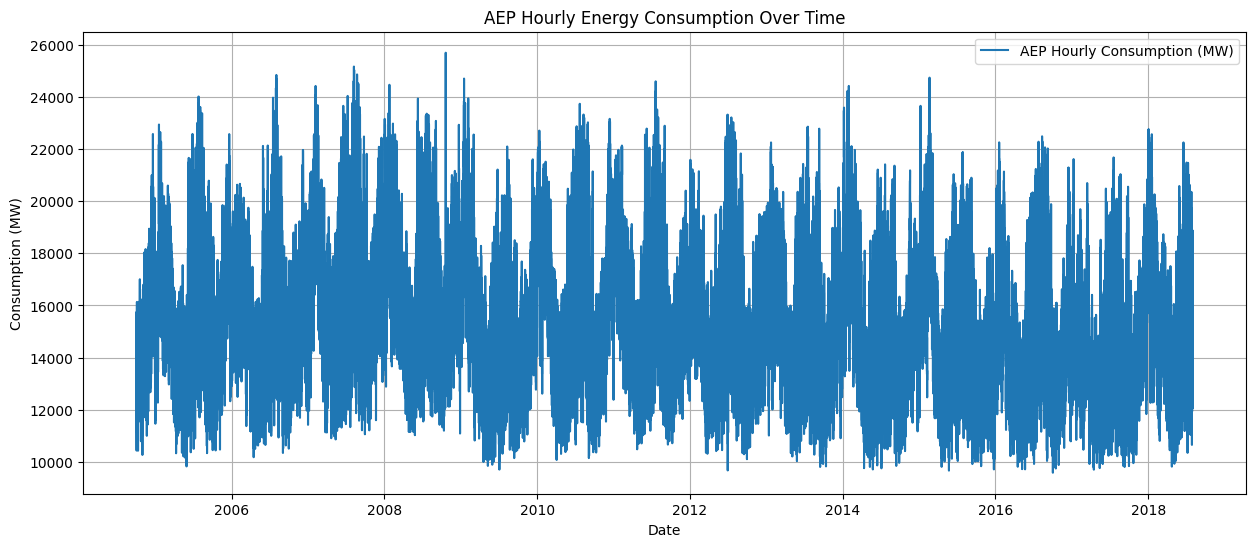

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/AEP_hourly.csv')

# Display the first few rows of the dataframe
print("Original Data Head:")
print(df.head())

# Get basic information about the dataframe
print("\nData Info:")
df.info()

# Convert 'Datetime' column to datetime objects
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Set 'Datetime' as the index
df = df.set_index('Datetime')

# Sort the index to ensure chronological order
df = df.sort_index()

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Resample data to hourly if there are any irregularities, and fill missing values if any
# For simplicity, we'll assume the data is already hourly and just check completeness
# If data is not perfectly hourly, you might need df = df.resample('H').mean()

# Rename the value column for clarity
df.rename(columns={'AEP_MW': 'Consumption_MW'}, inplace=True)

# Extract time-based features
df['Hour'] = df.index.hour
df['DayofWeek'] = df.index.dayofweek
df['DayofYear'] = df.index.dayofyear
df['Month'] = df.index.month
df['Year'] = df.index.year

print("\nData after preprocessing and feature engineering (head):")
print(df.head())

# Plot the time series to visualize the data
plt.figure(figsize=(15, 6))
plt.plot(df['Consumption_MW'], label='AEP Hourly Consumption (MW)')
plt.title('AEP Hourly Energy Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Consumption (MW)')
plt.legend()
plt.grid(True)
plt.show()

In [3]:
from sklearn.preprocessing import MinMaxScaler

# Select the target variable for scaling
data = df['Consumption_MW'].values.reshape(-1, 1)

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Define function to create sequences for Seq2Seq LSTM
def create_sequences(data, look_back, forecast_horizon):
    X, y = [], []
    for i in range(len(data) - look_back - forecast_horizon + 1):
        # Encoder input (past observations)
        X.append(data[i:(i + look_back), 0])
        # Decoder output (future observations)
        y.append(data[(i + look_back):(i + look_back + forecast_horizon), 0])
    return np.array(X), np.array(y)

# Define look_back and forecast_horizon
look_back = 24  # Use 24 hours of data to predict
forecast_horizon = 12  # Predict next 12 hours

X, y = create_sequences(scaled_data, look_back, forecast_horizon)

print(f"Shape of X (encoder input sequences): {X.shape}")
print(f"Shape of y (decoder output sequences): {y.shape}")

# Split data into training and testing sets
# We'll use 80% for training and 20% for testing
train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Reshape input to be 3D [samples, timesteps, features] for LSTM
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Reshape output to be 3D [samples, timesteps, features] for LSTM (decoder output)
y_train = y_train.reshape(y_train.shape[0], y_train.shape[1], 1)
y_test = y_test.reshape(y_test.shape[0], y_test.shape[1], 1)

print(f"\nReshaped X_train for LSTM: {X_train.shape}")
print(f"Reshaped y_train for LSTM: {y_train.shape}")
print(f"Reshaped X_test for LSTM: {X_test.shape}")
print(f"Reshaped y_test for LSTM: {y_test.shape}")

Shape of X (encoder input sequences): (121238, 24)
Shape of y (decoder output sequences): (121238, 12)
Shape of X_train: (96990, 24)
Shape of y_train: (96990, 12)
Shape of X_test: (24248, 24)
Shape of y_test: (24248, 12)

Reshaped X_train for LSTM: (96990, 24, 1)
Reshaped y_train for LSTM: (96990, 12, 1)
Reshaped X_test for LSTM: (24248, 24, 1)
Reshaped y_test for LSTM: (24248, 12, 1)


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Attention
from tensorflow.keras.optimizers import Adam

# Define the input shape for the encoder
encoder_inputs = Input(shape=(look_back, 1))

# Encoder LSTM
encoder_lstm = LSTM(units=64, return_sequences=True, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_states = [state_h, state_c]

# Set up the decoder
decoder_inputs = Input(shape=(forecast_horizon, 1))

# Decoder LSTM
decoder_lstm = LSTM(units=64, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)

# Attention mechanism
attention = Attention()([decoder_outputs, encoder_outputs])

# Concatenate attention output and decoder outputs
decoder_concat_input = tf.keras.layers.Concatenate(axis=-1, name='concat_layer')([decoder_outputs, attention])

# Dense layer to output the predicted sequence
decoder_dense = Dense(units=1, activation='linear')
output = decoder_dense(decoder_concat_input)

# Define the model
model = Model(inputs=[encoder_inputs, decoder_inputs], outputs=output)

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse')

# Print the model summary
print("Model Summary:")
model.summary()

Model Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 12, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 24, 64),  │     16,896 │ input_layer[0][0] │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 12, 64),  │     16,896 │ input_layer_1[0]… │
│                     │ (None, 64),       │            │ lstm[0][1],       │
│                     │ (None, 64)]       │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 12, 64)    │          0 │ lstm_1[0][0],     │
│ (Attention)         │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_layer        │ (None, 12, 128)   │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 12, 1)     │        129 │ concat_layer[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,921 (132.50 KB)

 Trainable params: 33,921 (132.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1516/1516 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.0072 - val_loss: 0.0042
Epoch 2/100
1516/1516 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.0040 - val_loss: 0.0026
Epoch 3/100
1516/1516 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0029 - val_loss: 0.0025
Epoch 4/100
1516/1516 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0027 - val_loss: 0.0024
Epoch 5/100
1516/1516 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0025 - val_loss: 0.0028
Epoch 6/100
1516/1516 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 7/100
1516/1516 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0023 - val_loss: 0.0030
Epoch 8/100
1516/1516 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0023 - val_loss: 0.0032
Epoch 9/100
1516/1516 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 10/100
1516/1516 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 11/100
1516/1516 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0020 - val_loss: 0.0021
Epoch 12

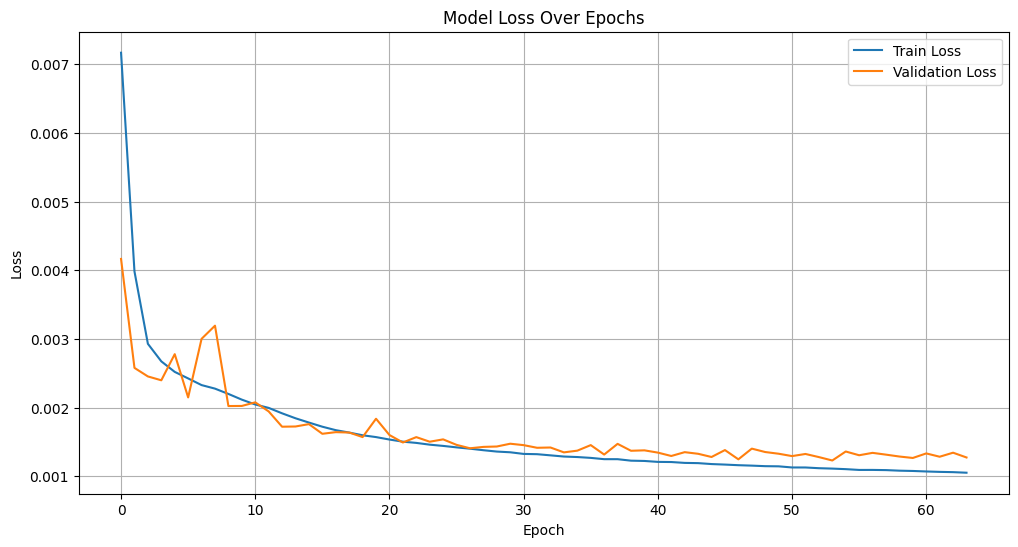

In [5]:
from tensorflow.keras.callbacks import EarlyStopping
decoder_input_data_train = np.zeros((y_train.shape[0], forecast_horizon, 1))
decoder_input_data_test = np.zeros((y_test.shape[0], forecast_horizon, 1))

# Define Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    [X_train, decoder_input_data_train],
    y_train,
    epochs=100,
    batch_size=64,
    validation_data=([X_test, decoder_input_data_test], y_test),
    callbacks=[early_stopping],
    verbose=1
)

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

758/758 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Root Mean Squared Error (RMSE): 565.32
Mean Absolute Error (MAE): 399.77


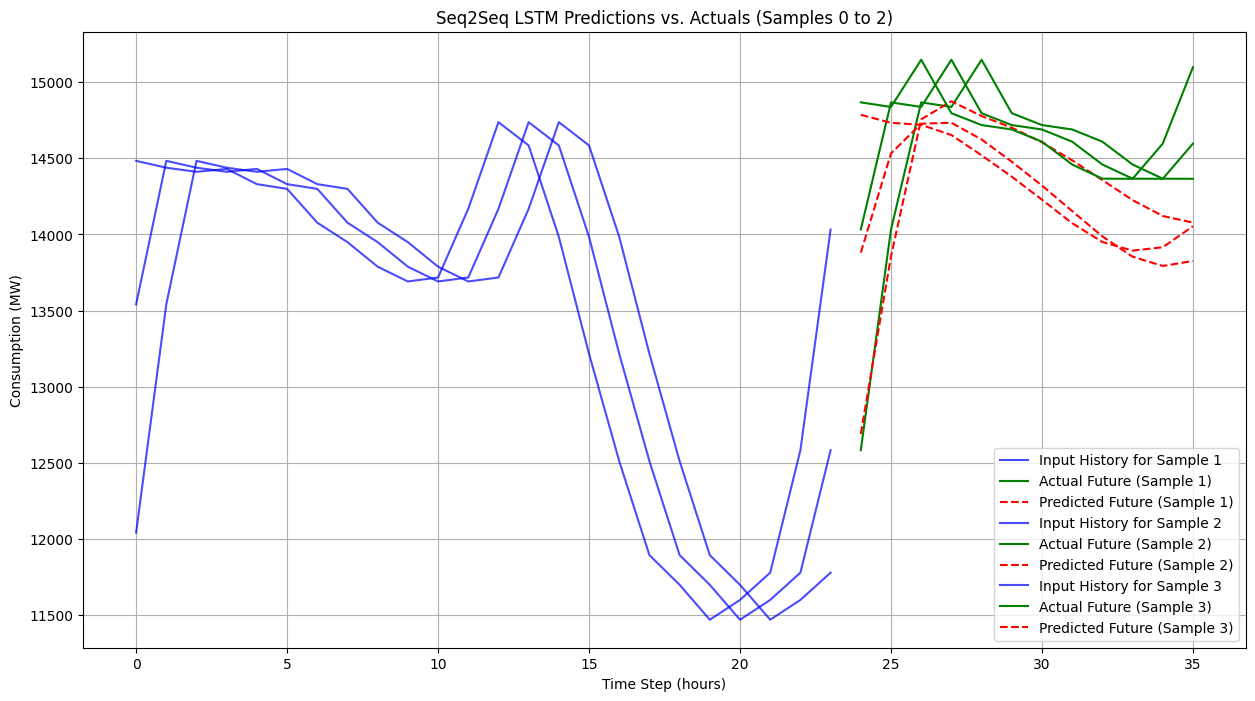


Visualizing a few individual forecast horizons:


<Figure size 2000x800 with 0 Axes>

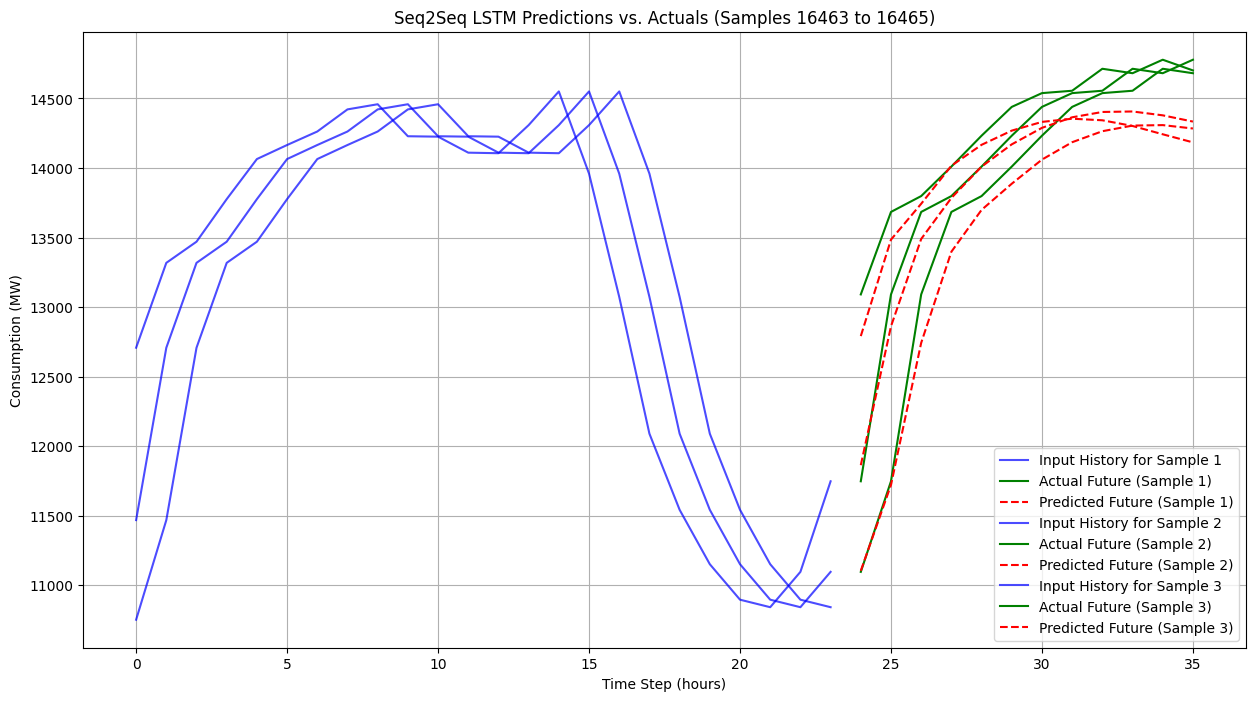

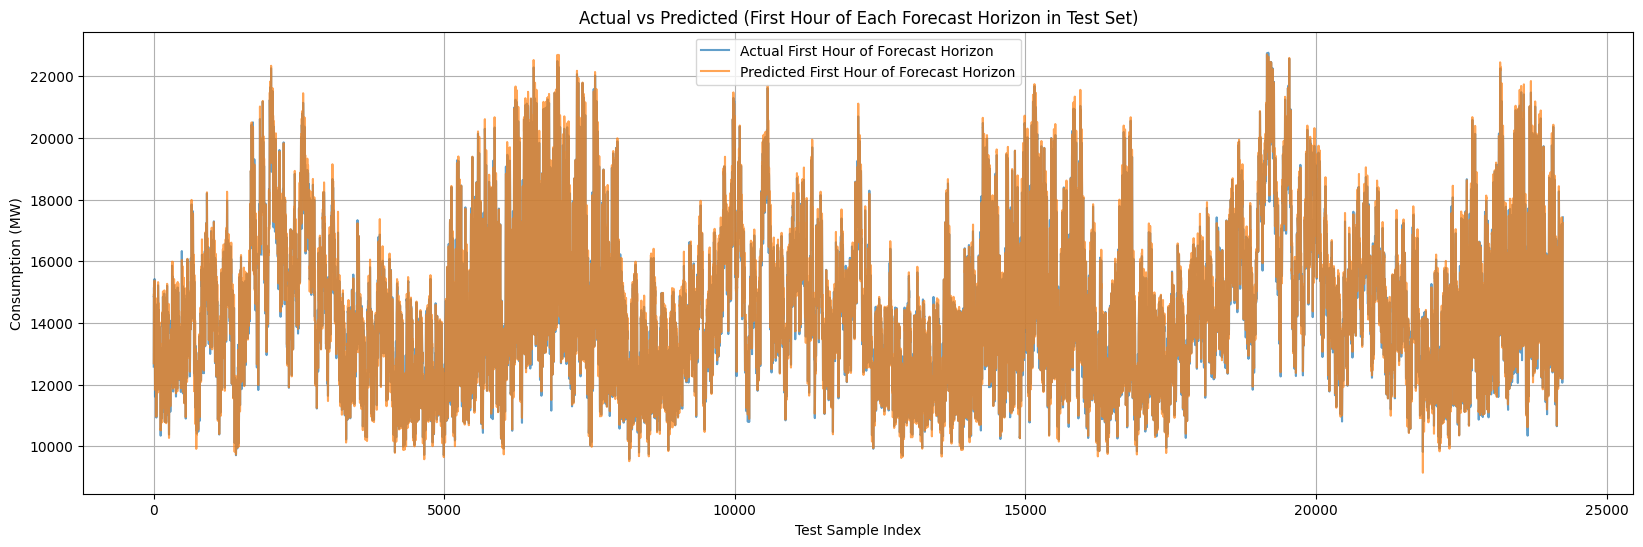

In [6]:
# Make predictions on the test data
predictions = model.predict([X_test, decoder_input_data_test])

# Inverse transform the predictions and actual values to the original scale
predictions_rescaled = scaler.inverse_transform(predictions.reshape(-1, forecast_horizon))
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, forecast_horizon))

# Calculate evaluation metrics (e.g., RMSE, MAE)
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(y_test_rescaled.flatten(), predictions_rescaled.flatten()))
mae = mean_absolute_error(y_test_rescaled.flatten(), predictions_rescaled.flatten())

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Visualize predictions vs. actual values for a few test samples
def plot_predictions(start_index, num_samples=5):
    plt.figure(figsize=(15, 8))
    for i in range(num_samples):
        idx = start_index + i
        if idx >= len(X_test):
            break

        plt.plot(range(look_back), scaler.inverse_transform(X_test[idx]).flatten(), label=f'Input History for Sample {i+1}', color='blue', alpha=0.7)
        plt.plot(range(look_back, look_back + forecast_horizon), y_test_rescaled[idx], label=f'Actual Future (Sample {i+1})', color='green')
        plt.plot(range(look_back, look_back + forecast_horizon), predictions_rescaled[idx], label=f'Predicted Future (Sample {i+1})', color='red', linestyle='--')

    plt.title(f'Seq2Seq LSTM Predictions vs. Actuals (Samples {start_index} to {start_index + num_samples - 1})')
    plt.xlabel('Time Step (hours)')
    plt.ylabel('Consumption (MW)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot predictions for the first few test samples
plot_predictions(0, num_samples=3)

# You might also want to plot a longer sequence for better overview
# Select a random starting point for a longer plot
import random
random_start_index = random.randint(0, len(X_test) - 200)
plt.figure(figsize=(20, 8))

# For plotting a continuous sequence, we need to iterate and plot segment by segment
# This is a bit more complex as X_test and y_test are sequence-based, not continuous
# Let's simplify and plot one long sequence of actual vs predicted if we were to chain predictions.
# For now, we'll just show several individual predictions

print("\nVisualizing a few individual forecast horizons:")
plot_predictions(random_start_index, num_samples=3)

# To get a more overall picture, we can plot the entire test set predictions against actuals
# This requires reconstructing the full series from the sequences for both actual and predicted.
# For simplicity, let's just take the first predicted horizon of each test sequence and plot against actuals.
# Note: This is an approximation and not a true step-by-step rolling forecast.

plt.figure(figsize=(20, 6))
plt.plot(y_test_rescaled[:, 0], label='Actual First Hour of Forecast Horizon', alpha=0.7)
plt.plot(predictions_rescaled[:, 0], label='Predicted First Hour of Forecast Horizon', alpha=0.7)
plt.title('Actual vs Predicted (First Hour of Each Forecast Horizon in Test Set)')
plt.xlabel('Test Sample Index')
plt.ylabel('Consumption (MW)')
plt.legend()
plt.grid(True)
plt.show()

Given that extreme weather introduces sudden, non-linear spikes, how can we prevent the LSTM from over-smoothing its predictions during unprecedented climate events?

#2. Human Activity Recognition (HAR) via Smartphone Telemetry

Use raw 3D accelerometer and gyroscope data sequences from edge devices (smartphones/wearables) to classify complex physical human behaviors (e.g., falling vs. sitting down quickly).

In [14]:
# First, ensure the dataset is unzipped if it's in a zip file.
# Assuming the outer zip file 'human+activity+recognition+using+smartphones.zip' is in /content/
import os
import shutil # Import shutil for rmtree

outer_zip_file_path = '/content/human+activity+recognition+using+smartphones.zip'
inner_zip_file_name = 'UCI HAR Dataset.zip'
extraction_path = '/content/' # The outer zip will extract files here

# Clean up any previous extraction attempts to avoid prompts and ensure fresh data
# Remove the target data directory if it exists
final_data_dir = os.path.join(extraction_path, 'UCI HAR Dataset')
if os.path.exists(final_data_dir):
    print(f"Removing existing '{final_data_dir}' directory...")
    shutil.rmtree(final_data_dir)

# Remove the inner zip file if it was extracted but not processed
inner_zip_path = os.path.join(extraction_path, inner_zip_file_name)
if os.path.exists(inner_zip_path):
    print(f"Removing existing '{inner_zip_file_name}' file...")
    os.remove(inner_zip_path)

# Also remove the problematic 'UCI HAR Dataset.names' file if it exists directly in /content/
if os.path.exists(os.path.join(extraction_path, 'UCI HAR Dataset.names')):
    print("Removing existing 'UCI HAR Dataset.names' file...")
    os.remove(os.path.join(extraction_path, 'UCI HAR Dataset.names'))

print(f"Unzipping outer archive '{outer_zip_file_path}' to '{extraction_path}'...")
# Use -o (overwrite) and -q (quiet) for silent unzipping
!unzip -o -q "{outer_zip_file_path}" -d "{extraction_path}"
print("Outer unzipping complete.")

# Now, unzip the inner 'UCI HAR Dataset.zip' file that was just extracted
if os.path.exists(inner_zip_path):
    print(f"Unzipping inner archive '{inner_zip_file_name}' to '{extraction_path}'...")
    !unzip -o -q "{inner_zip_path}" -d "{extraction_path}"
    print("Inner unzipping complete.")
else:
    print(f"Error: Inner zip file '{inner_zip_file_name}' not found after outer extraction. Please check the content of your uploaded zip file.")

# Inspect the extracted directory structure to find the actual path
print("\nListing contents of /content/:")
!ls -R /content/

import numpy as np
import pandas as pd

# Define the path to the dataset, now assuming correct extraction
DATASET_PATH = '/content/UCI HAR Dataset/'

# Load the training data
X_train_path = DATASET_PATH + 'train/X_train.txt'
y_train_path = DATASET_PATH + 'train/y_train.txt'

# Add a final check to confirm path before loading
if not os.path.exists(X_train_path):
    print(f"Critical Error: {X_train_path} still not found after unzipping. Check file structure.")
    raise FileNotFoundError(f"Expected file not found at: {X_train_path}")

X_train = np.loadtxt(X_train_path)
y_train = np.loadtxt(y_train_path)

# Load the test data
X_test_path = DATASET_PATH + 'test/X_test.txt'
y_test_path = DATASET_PATH + 'test/y_test.txt'

X_test = np.loadtxt(X_test_path)
y_test = np.loadtxt(y_test_path)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Also load the activity labels to understand the target variable
activity_labels_path = DATASET_PATH + 'activity_labels.txt'
activity_labels = pd.read_csv(activity_labels_path, sep=' ', header=None, names=['label_id', 'activity_name'])
print("\nActivity Labels:")
print(activity_labels.head())

Removing existing '/content/UCI HAR Dataset' directory...
Removing existing 'UCI HAR Dataset.zip' file...
Removing existing 'UCI HAR Dataset.names' file...
Unzipping outer archive '/content/human+activity+recognition+using+smartphones.zip' to '/content/'...
Outer unzipping complete.
Unzipping inner archive 'UCI HAR Dataset.zip' to '/content/'...
Inner unzipping complete.

Listing contents of /content/:
/content/:
 AEP_hourly.csv					    __MACOSX
 COMED_hourly.csv				    NI_hourly.csv
 DAYTON_hourly.csv				    PJME_hourly.csv
 DEOK_hourly.csv				    pjm_hourly_est.csv
 DOM_hourly.csv					    PJM_Load_hourly.csv
 DUQ_hourly.csv					    PJMW_hourly.csv
 EKPC_hourly.csv				    sample_data
 est_hourly.paruqet				   'UCI HAR Dataset'
 FE_hourly.csv					   'UCI HAR Dataset.names'
 human+activity+recognition+using+smartphones.zip  'UCI HAR Dataset.zip'

/content/__MACOSX:
'UCI HAR Dataset'

'/content/__MACOSX/UCI HAR Dataset':
test  train

'/content/__MACOSX/UCI HAR Dataset/test':
'Inertial Si

In [15]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Encode target labels to start from 0 for to_categorical
# y_train and y_test currently have labels 1-6
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Convert to one-hot encoding
y_train_one_hot = to_categorical(y_train_encoded)
y_test_one_hot = to_categorical(y_test_encoded)

num_classes = y_train_one_hot.shape[1]
print(f"Number of classes: {num_classes}")
print(f"Shape of y_train_one_hot: {y_train_one_hot.shape}")
print(f"Shape of y_test_one_hot: {y_test_one_hot.shape}")

Number of classes: 6
Shape of y_train_one_hot: (7352, 6)
Shape of y_test_one_hot: (2947, 6)


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the FNN model
model_har = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # Output layer with softmax for multi-class classification
])

# Compile the model
optimizer_har = Adam(learning_rate=0.001)
model_har.compile(optimizer=optimizer_har, loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
print("HAR Model Summary:")
model_har.summary()

HAR Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │       143,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177,542 (693.52 KB)

 Trainable params: 177,542 (693.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4513 - loss: 1.3018
Epoch 1: val_accuracy improved from None to 0.92862, saving model to best_har_model.keras

Epoch 1: finished saving model to best_har_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.6028 - loss: 0.9365 - val_accuracy: 0.9286 - val_loss: 0.3502
Epoch 2/100
82/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7863 - loss: 0.4926
Epoch 2: val_accuracy did not improve from 0.92862
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8113 - loss: 0.4442 - val_accuracy: 0.9279 - val_loss: 0.2204
Epoch 3/100
88/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8602 - loss: 0.3335
Epoch 3: val_accuracy improved from 0.92862 to 0.93474, saving model to best_har_model.keras

Epoch 3: finished saving model to best_har_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8718 - loss: 0.3102 - val_accuracy: 0.9347 - val_loss: 0.1996
Epoch 4/100
87/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step -

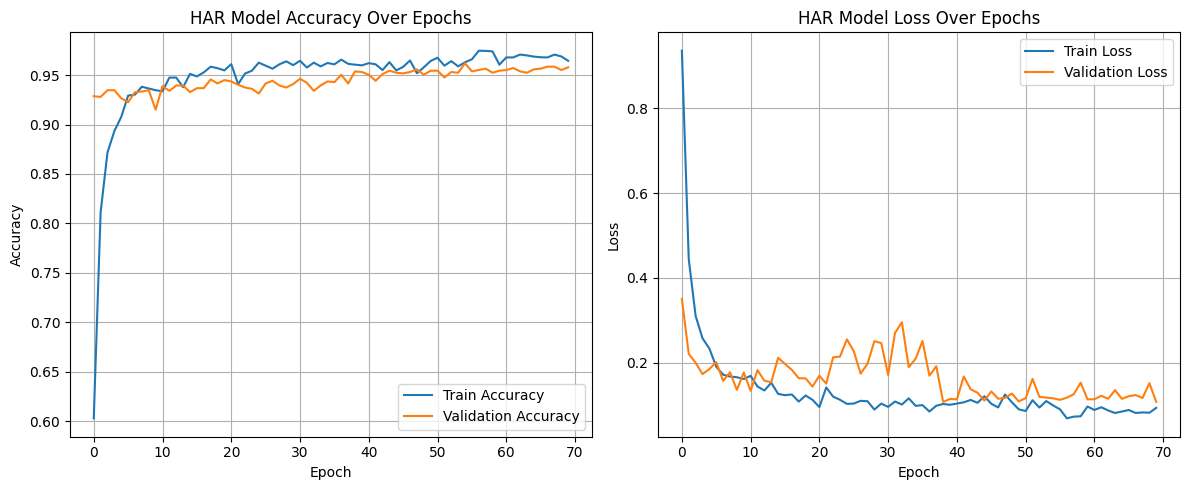

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define Early Stopping callback
early_stopping_har = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1)

# Define ModelCheckpoint to save the best model during training
model_checkpoint_har = ModelCheckpoint('best_har_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)

# Train the model
history_har = model_har.fit(
    X_train,
    y_train_one_hot,
    epochs=100, # Increased epochs, but early stopping will manage actual training duration
    batch_size=64,
    validation_split=0.2, # Use a portion of training data for validation
    callbacks=[early_stopping_har, model_checkpoint_har],
    verbose=1
)

print("\nTraining complete.")

# Plot training & validation accuracy and loss values
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_har.history['accuracy'], label='Train Accuracy')
plt.plot(history_har.history['val_accuracy'], label='Validation Accuracy')
plt.title('HAR Model Accuracy Over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_har.history['loss'], label='Train Loss')
plt.plot(history_har.history['val_loss'], label='Validation Loss')
plt.title('HAR Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

Dataset Link UCI Machine Learning Repository: Human Activity Recognition Using Smartphones https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip